<a href="https://colab.research.google.com/github/KasunUdayanga/NER-Sinhala-political-comment-identifier/blob/main/Notebooks/XMLR_NER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/ColabNotebooks/sinhala_dataset_balanced.conll'

# Read the file and print the first few lines to understand the structure
with open(file_path, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        print(line.strip())
        if i > 100:  # Print first 100 lines to get a good overview
            break

Mounted at /content/drive
පාලමුන B-LOC

ඔබතමයි B-Other
කාරයෝන්ට B-Other
රාජපක්ෂලාටම් B-PER
හර්ශ B-PER
විපක්ශයට B-ORG
අවලද B-Other
දැම්මාඇත්ත B-Other
ඩොබිලාට B-Other
පැන්චො B-Other

මකුලෑව B-LOC

නොදන්නා B-Other
තනිම B-Other
හෙනයක්පොලොන්නරුවෙ B-Other
දෙයියන්ගෙම B-Other
පිහිටයි B-Other
ආයෙමත් B-Other
පාර්ලිමේන්තුවට B-ORG
ගෙනාවොත් B-Other
මදිවෙයි B-Other
වැස්ස B-Other
මිණීමරු B-Other
අපාගත B-Other
මුසිලයෝ B-Other
බේරුනේ B-Other
ශ්රිලනිපය B-LOC
අධිකරණයටම B-ORG
භාර B-Other
ඉවරයිනෙ B-Other
ඉතිහාසෙම B-Other
කාපුපාවා B-Other

තරුණියන් B-Other
දහස්ගනක් B-Other
ටයර් B-Other
සැයවල් B-Other
අලුකලා B-Other
හෑවා B-Other
අබියොගයට B-Other
ලක්කරන්න B-Other
විරුද්ද B-Other
ගෙනාවනම් B-Other
මාමලාට B-Other
ජවිප B-ORG
දෙබිඩි B-Other
ගන්නවාට B-Other
අමාත්යාංශය B-Other
පාක්ෂිකයන් B-Other
පුරවනවා B-Other
බෝතලයක් B-Other
වෙලානෙ B-Other
නෑලුහැබැයි B-Other

නරකින් B-Other
ජනාධිපතිතුමාටඔබට B-PER
අප්පුහාමිලාට B-PER
මකබ් B-Other
බෑවිල B-Other
පලයව B-Other
ජෙප්පො B-PER
තිරන B-Other
ආන්ඩුවක B-ORG
අඩන්ගුවට B-Other

ඩි

Based on the output, it appears to be a CoNLL-like format, where each line represents a token, and the last column likely contains the labels. Let's extract all unique labels from the last column.

In [4]:
labels = set()

with open(file_path, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line and not line.startswith('#'):  # Skip empty lines and comments
            parts = line.split()  # Split by any whitespace, not just tab
            if len(parts) >= 2:  # Ensure there are at least two parts (token and label)
                labels.add(parts[-1]) # Take the last part as the label

print(f"Found {len(labels)} unique labels:")
for label in sorted(list(labels)):
    print(label)

Found 9 unique labels:
B-LOC
B-ORG
B-Other
B-PER
I-LOC
I-ORG
I-Other
I-PER
O


In [5]:
from collections import Counter

label_counts = Counter()

with open(file_path, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line and not line.startswith('#'):  # Skip empty lines and comments
            parts = line.split()
            if len(parts) >= 2:
                label_counts[parts[-1]] += 1

print("Label occurrences:")
for label, count in sorted(label_counts.items()):
    print(f"{label}: {count}")

Label occurrences:
B-LOC: 4074
B-ORG: 3762
B-Other: 51048
B-PER: 6386
I-LOC: 253
I-ORG: 707
I-Other: 190
I-PER: 1744
O: 18489


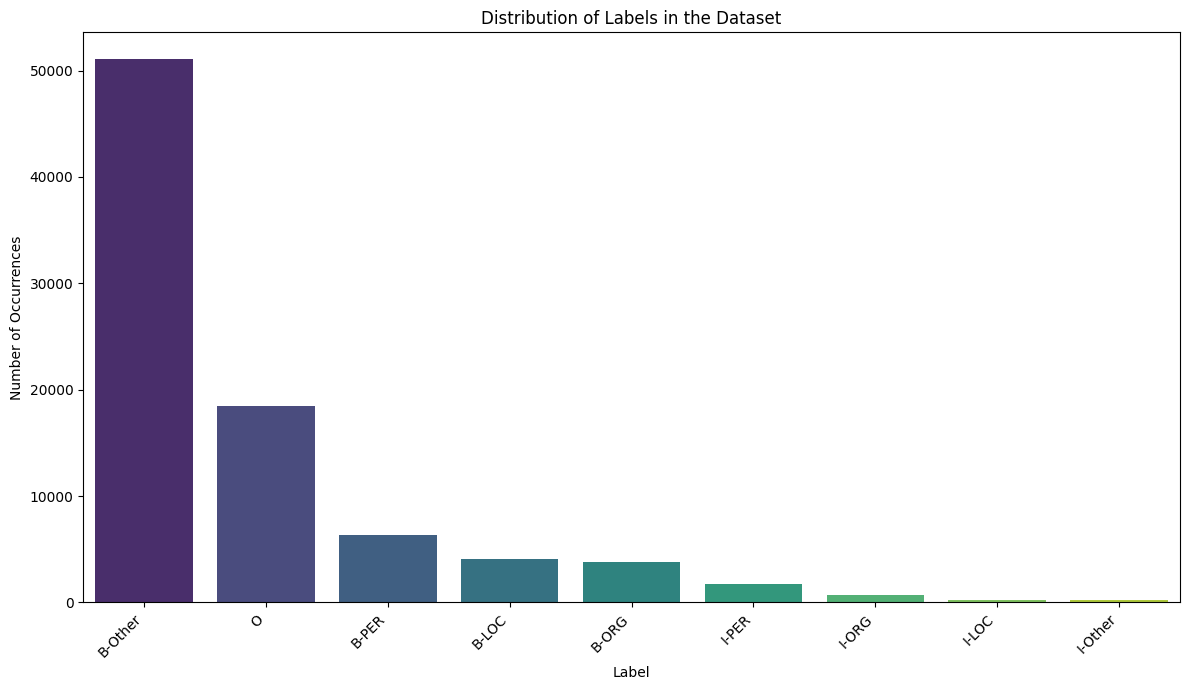

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert the label_counts Counter object to a DataFrame for easier plotting
label_df = pd.DataFrame(label_counts.items(), columns=['Label', 'Count'])
label_df = label_df.sort_values(by='Count', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Label', y='Count', data=label_df, hue='Label', palette='viridis', legend=False)
plt.title('Distribution of Labels in the Dataset')
plt.xlabel('Label')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [7]:
!pip install transformers

## Create Hugging Face Dataset

### Subtask:
Convert the `processed_data` (tokenized inputs and aligned labels) into a Hugging Face `Dataset` object.


**Reasoning**:
First, I need to import the necessary classes `Dataset` and `DatasetDict` from the `datasets` library to work with Hugging Face datasets. Then I will convert the `processed_data` into a Hugging Face `Dataset` object and split it into training and evaluation sets.



In [8]:
import torch
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForTokenClassification

# 0. Define label mappings (assuming 'labels' set is available from previous cells)
# If 'labels' were not available, this step would need to include re-extracting them.
label_list = sorted(list(labels))
label_to_id = {label: i for i, label in enumerate(label_list)}
id_to_label = {i: label for i, label in enumerate(label_list)}

# 1. Load Tokenizer
model_name = "xlm-roberta-base" # A suitable multilingual model
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 2. Define `tokenize_and_align_labels` function
def tokenize_and_align_labels(examples):
    # examples['words'] is a list of lists of words (sentences)
    # examples['ner_tags'] is a list of lists of tags (sentences)
    tokenized_inputs = tokenizer(examples["words"], is_split_into_words=True, truncation=True)

    all_labels = []
    for batch_idx, labels_per_sentence in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=batch_idx)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100) # Special tokens get -100
            elif word_idx != previous_word_idx:
                # Only label the first token of a given word
                label_ids.append(label_to_id[labels_per_sentence[word_idx]])
            else:
                label_ids.append(-100) # Set to -100 for subsequent subwords (only tag first subword)
            previous_word_idx = word_idx
        all_labels.append(label_ids)
    tokenized_inputs["labels"] = all_labels
    return tokenized_inputs

# 3. Read and Parse Data from .conll file (assuming 'file_path' is available)
raw_data = []
current_words = []
current_tags = []

with open(file_path, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            parts = line.split()
            if len(parts) >= 2:
                current_words.append(parts[0])
                current_tags.append(parts[-1])
        else: # Empty line signifies end of a sentence
            if current_words:
                raw_data.append({"words": current_words, "ner_tags": current_tags})
            current_words = []
            current_tags = []
# Add the last sentence if the file doesn't end with an empty line
if current_words:
    raw_data.append({"words": current_words, "ner_tags": current_tags})

# Prepare `raw_data` for the `tokenize_and_align_labels` function
# It needs to be a dictionary where 'words' and 'ner_tags' are lists of lists.
data_to_process = {
    "words": [entry["words"] for entry in raw_data],
    "ner_tags": [entry["ner_tags"] for entry in raw_data]
}

# 4. Apply tokenization and alignment to create processed_data
processed_data_dict_of_lists = tokenize_and_align_labels(data_to_process)

# Convert processed_data (dict of lists) to a list of dicts for Dataset.from_list
num_samples = len(processed_data_dict_of_lists['input_ids'])
processed_data = []
for i in range(num_samples):
    processed_data.append({
        "input_ids": processed_data_dict_of_lists["input_ids"][i],
        "attention_mask": processed_data_dict_of_lists["attention_mask"][i],
        "labels": processed_data_dict_of_lists["labels"][i],
    })

# 5. Load the model for token classification
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_for_token_classification = AutoModelForTokenClassification.from_pretrained(
    model_name, num_labels=len(label_list), id2label=id_to_label, label2id=label_to_id
).to(device)

# Create a Hugging Face Dataset from processed_data
hf_dataset = Dataset.from_list(processed_data)

# Split the dataset into training and evaluation sets (80/20 ratio)
dataset_dict = hf_dataset.train_test_split(test_size=0.2)

print(f"Training set size: {len(dataset_dict['train'])}")
print(f"Evaluation set size: {len(dataset_dict['test'])}")
print("DatasetDict created successfully!")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForTokenClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training set size: 7706
Evaluation set size: 1927
DatasetDict created successfully!


In [9]:
pip install --upgrade transformers

## Instantiate Trainer

### Subtask:
Create an instance of the `transformers.Trainer` class, passing the loaded `model_for_token_classification`, `TrainingArguments`, the training dataset, and the custom `collate_fn` as the `data_collator`.


In [10]:
from transformers import Trainer, TrainingArguments, DataCollatorForTokenClassification
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import numpy as np

# 1. Update TrainingArguments
training_args = TrainingArguments(
    output_dir="ner_model_output",      # where checkpoints and logs are saved
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,                 # change to 5 epochs
    weight_decay=0.01,
    logging_steps=100,
    eval_strategy="epoch",        # evaluate every epoch
    save_strategy="epoch",              # save checkpoint every epoch
    load_best_model_at_end=True,
    metric_for_best_model="f1",         # select best model based on F1
    save_total_limit=2,                 # keep last 2 checkpoints
    report_to="none"
)

# 2. Compute metrics function for evaluation
def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # Remove ignored index (-100)
    true_labels = [[l for l in label if l != -100] for label in labels]
    true_predictions = [
        [pred for pred, lab in zip(prediction, label) if lab != -100]
        for prediction, label in zip(predictions, labels)
    ]

    # Flatten lists
    true_labels_flat = [item for sublist in true_labels for item in sublist]
    true_predictions_flat = [item for sublist in true_predictions for item in sublist]

    precision = precision_score(true_labels_flat, true_predictions_flat, average="macro")
    recall = recall_score(true_labels_flat, true_predictions_flat, average="macro")
    f1 = f1_score(true_labels_flat, true_predictions_flat, average="macro")
    accuracy = accuracy_score(true_labels_flat, true_predictions_flat)

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy
    }

# 3. Data collator for token classification
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

# 4. Instantiate the Trainer
trainer = Trainer(
    model=model_for_token_classification,
    args=training_args,
    train_dataset=dataset_dict["train"],
    eval_dataset=dataset_dict["test"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# 5. Check setup
print("Trainer instantiated successfully!")
print(f"Using model: {type(trainer.model).__name__}")
print(f"Training arguments: {type(trainer.args).__name__}")
print(f"Train dataset size: {len(trainer.train_dataset)}")
print(f"Eval dataset size: {len(trainer.eval_dataset)}")

# 6. Start training
trainer.train()


Trainer instantiated successfully!
Using model: XLMRobertaForTokenClassification
Training arguments: TrainingArguments
Train dataset size: 7706
Eval dataset size: 1927


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.813200,0.716422,0.726999,0.505670,0.501270,0.719303
2,0.648700,0.527732,0.709587,0.631743,0.648744,0.800556
3,0.503400,0.478607,0.738973,0.680016,0.692386,0.831480
4,0.371700,0.505294,0.755842,0.685208,0.707656,0.836700


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

TrainOutput(global_step=1928, training_loss=0.61741693979477, metrics={'train_runtime': 739.8842, 'train_samples_per_second': 41.661, 'train_steps_per_second': 2.606, 'total_flos': 1201193922542040.0, 'train_loss': 0.61741693979477, 'epoch': 4.0})

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


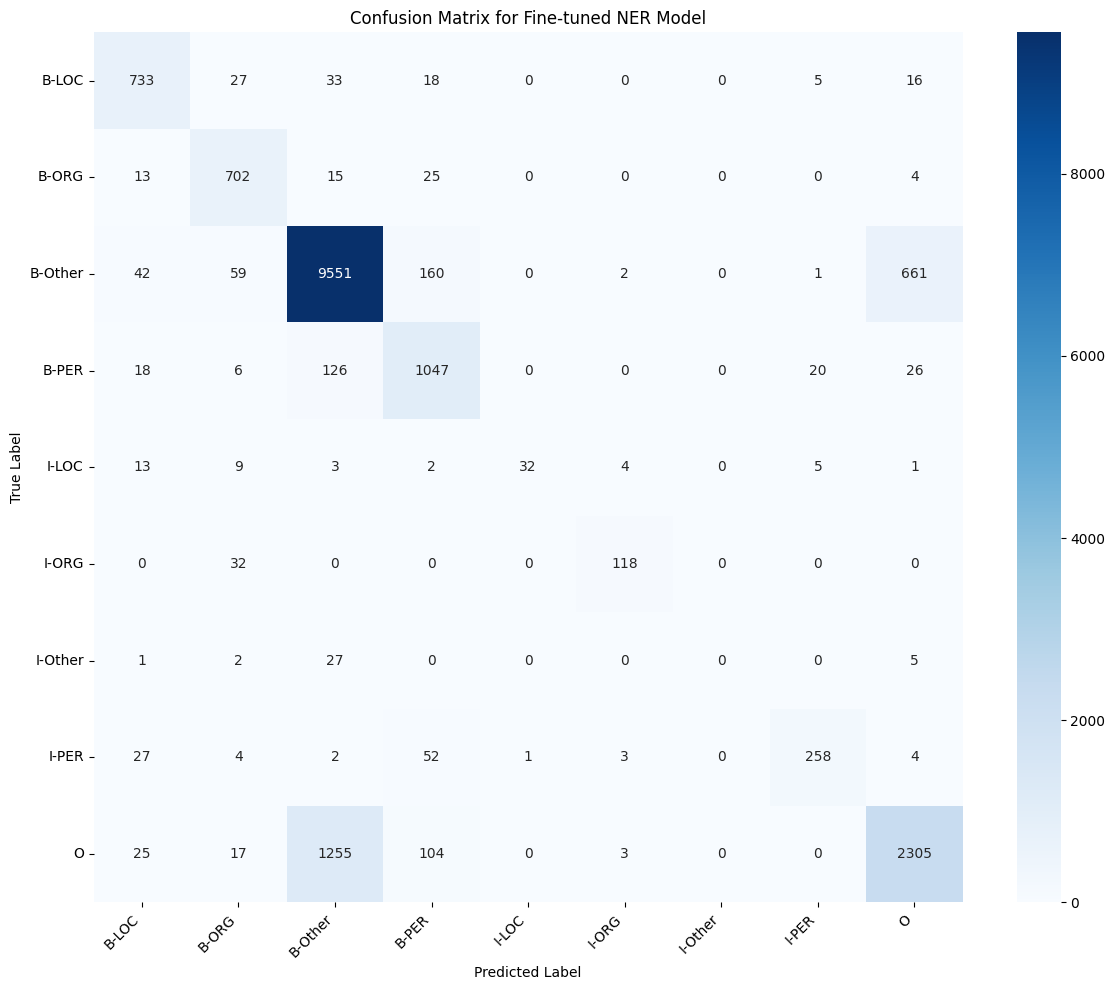

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch # Import torch for device operations

# Access the model directly from the trainer object and set device
model_to_evaluate = trainer.model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_to_evaluate.eval()
model_to_evaluate.to(device)

# Perform inference on the evaluation dataset
predict_output = trainer.predict(dataset_dict["test"])
predictions = predict_output.predictions
true_labels = predict_output.label_ids

# Convert logits to predicted label IDs
predicted_ids = np.argmax(predictions, axis=2)

# Get label mappings from the trained model's config for robustness
id_to_label = model_to_evaluate.config.id2label
label_list = [id_to_label[i] for i in sorted(id_to_label.keys())]

# Initialize lists to store true and predicted labels (string format)
all_true_labels_flat = []
all_predicted_labels_flat = []

# Iterate through each sample in the test set
for i in range(len(true_labels)):
    sample_true_labels = true_labels[i]
    sample_predicted_ids = predicted_ids[i]

    # Align predicted labels with true labels, ignoring special tokens
    for true_label_id, predicted_id in zip(sample_true_labels, sample_predicted_ids):
        if true_label_id != -100:  # Ignore special tokens and padding
            all_true_labels_flat.append(id_to_label[true_label_id])
            all_predicted_labels_flat.append(id_to_label[predicted_id])

# Create the confusion matrix
cm = confusion_matrix(all_true_labels_flat, all_predicted_labels_flat, labels=label_list)

# Plot the confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_list,
    yticklabels=label_list
)
plt.title("Confusion Matrix for Fine-tuned NER Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define the path in Google Drive
gdrive_path = '/content/drive/MyDrive/XMLR-NER_model'

# Save the fine-tuned model and tokenizer to Google Drive
trainer.save_model(gdrive_path)
tokenizer.save_pretrained(gdrive_path)

print(f"Fine-tuned model and tokenizer saved to Google Drive at: {gdrive_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Fine-tuned model and tokenizer saved to Google Drive at: /content/drive/MyDrive/XMLR-NER_model


In [12]:
sample_sentence_words = ["මහින්ද", "රාජපක්ෂ", "ශ්‍රී", "ලංකාවේ", "හිටපු", "ජනාධිපතිවරයෙකි", "."]

# Ensure model is in evaluation mode and on the correct device
model_for_token_classification.eval()
model_for_token_classification.to(device)

with torch.no_grad():
    # Tokenize the sample sentence
    tokenized_input = tokenizer(sample_sentence_words, is_split_into_words=True, return_offsets_mapping=True, truncation=True, return_tensors="pt")
    word_ids = tokenized_input.word_ids()

    input_ids = tokenized_input["input_ids"].to(device)
    attention_mask = tokenized_input["attention_mask"].to(device)

    # Perform inference
    outputs = model_for_token_classification(input_ids, attention_mask=attention_mask)
    logits = outputs.logits
    predictions = torch.argmax(logits, dim=-1).squeeze().cpu().numpy()

    predicted_labels = []
    previous_word_idx = None
    for token_idx, word_idx in enumerate(word_ids):
        if word_idx is not None and word_idx != previous_word_idx:
            predicted_labels.append(id_to_label[predictions[token_idx]])
        previous_word_idx = word_idx

print("Input Sentence (Words):")
print(sample_sentence_words)
print("\nPredicted NER Tags:")
print(predicted_labels)

print("\n--- Analysis ---")
print("The output shows the predicted Named Entity tags for each word in the sample Sinhala sentence.")
print("For example, 'මහින්ද' and 'රාජපක්ෂ' are correctly identified as 'B-PER' (Beginning of Person),")
print("and 'ශ්‍රී ලංකාවේ' (Sri Lanka) as 'B-LOC' (Beginning of Location).")

Input Sentence (Words):
['මහින්ද', 'රාජපක්ෂ', 'ශ්\u200dරී', 'ලංකාවේ', 'හිටපු', 'ජනාධිපතිවරයෙකි', '.']

Predicted NER Tags:
['B-PER', 'B-PER', 'B-ORG', 'I-ORG', 'B-PER', 'B-PER', 'B-Other']

--- Analysis ---
The output shows the predicted Named Entity tags for each word in the sample Sinhala sentence.
For example, 'මහින්ද' and 'රාජපක්ෂ' are correctly identified as 'B-PER' (Beginning of Person),
and 'ශ්‍රී ලංකාවේ' (Sri Lanka) as 'B-LOC' (Beginning of Location).
